# 3. Digital Twin Fitting & Validation

Create and validate the digital twin simulator.

## 3.0 Install Dependencies

In [1]:
# Install required packages (safe to re-run; --quiet suppresses noise)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'pandas',
    'pyarrow',
    'numpy',
    'scipy',
    'simpy',
    'scikit-learn',
    'joblib',
    'matplotlib',
    'seaborn'
])


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


0

## 3.1 Setup

In [2]:
import sys; from pathlib import Path
_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / 'src' / 'data_ingestion.py').exists():
        _repo_root = _p
        _src = str(_p / 'src')
        if _src not in sys.path: sys.path.insert(0, _src)
        break
DATASET = "BPIC2012"
OUTPUT_DIR = _repo_root / 'output' / DATASET
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3.1 Load Data

In [3]:
import pandas as pd
df = pd.read_parquet(OUTPUT_DIR / f'events_{DATASET}_train.parquet')
print(f"Loaded {len(df)} events")

Loaded 262200 events


## 3.2 Fit Twin

> The fitted twin is used by `ProcessEnv` which now exposes a `MultiDiscrete([max_successors, 15])` action space — routing decisions combined with 15 KPI-based management actions (see `src/kpi_actions.py`).

In [4]:
import joblib
from digital_twin import DigitalTwin
twin = DigitalTwin(max_trace_len=200, seed=42)
twin.fit(df)
joblib.dump(twin, OUTPUT_DIR / f'digital_twin_{DATASET}_train.pkl')
print(f"Fitted twin with {len(twin.activities)} activities")

Fitted twin with 24 activities


## 3.3 Simulate

In [5]:
sim_df = twin.simulate(n_cases=df['case_id'].nunique())
sim_df.to_parquet(OUTPUT_DIR / 'sim_events_modeA.parquet', engine='pyarrow', index=False)
print(f"Generated {len(sim_df)} events")

Generated 251988 events


## 3.4 Validate

In [6]:
import json
from validation import validate, DEFAULT_THRESHOLDS
results = validate(df, sim_df, DEFAULT_THRESHOLDS)
with open(OUTPUT_DIR / 'validation_modeA.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Validation:', results.get('overall_pass', False))

  ✓ PASS  trace_length_wasserstein            = 0.7803  (threshold ≤ 3.0)


  ✓ PASS  case_duration_wasserstein           = 0.0301  (threshold ≤ 0.15)
  ✓ PASS  activity_freq_jsd                   = 0.0016  (threshold ≤ 0.05)


  ✓ PASS  transition_matrix_l1                = 0.0025  (threshold ≤ 0.1)


  ✓ PASS  duration_distribution_ks            = 0.0163  (threshold ≤ 0.2)


  ✓ PASS  variant_coverage                    = 1.0000  (threshold ≥ 0.8)
  ✓ PASS  resource_utilisation_mae            = 0.0001  (threshold ≤ 0.05)


  ✗ FAIL  cycle_time_scale_error              = 0.7117  (threshold ≤ 0.4)

  Overall: ✗ FAIL
Validation: False


## 3.5 Validation Metrics Reference

| Metric | What it measures | Scale | Direction | Threshold |
|---|---|---|---|---|
| `trace_length_wasserstein` | Earth Mover's Distance between real and simulated trace length distributions. Penalises simulators that generate traces that are too short or too long on average. | Events (unbounded) | Lower is better | < 3.0 |
| `case_duration_wasserstein` | EMD between normalised [0,1] case duration shapes. Compares the *shape* of duration distributions rather than absolute scale, since the sim captures processing time while real data includes waiting time. | [0, 1] | Lower is better | < 0.15 |
| `activity_freq_jsd` | Jensen-Shannon Divergence on activity frequency distributions. Measures whether the sim generates activities in the same proportions as the real log. JSD is symmetric and bounded. | [0, 1] | Lower is better | < 0.05 |
| `transition_matrix_l1` | Mean L1 distance per cell of the empirical transition matrices. Checks whether the sim routes cases through the same activity sequences as the real process. | [0, 1] | Lower is better | < 0.10 |
| `duration_distribution_ks` | Mean Kolmogorov-Smirnov statistic on per-activity duration CDFs (log-scale). Measures how well the sim reproduces the duration distribution of each individual activity. | [0, 1] | Lower is better | < 0.20 |
| `variant_coverage` | Fraction of activity bigrams from the top-50 most frequent real traces that appear in the simulation. Tests structural coverage of common process paths. | [0, 1] | Higher is better | > 0.80 |
| `resource_utilisation_mae` | Mean absolute error on per-resource utilisation fractions. Checks whether the sim assigns work to resources in the same proportions as the real log. | [0, 1] | Lower is better | < 0.05 |

> Thresholds are informed by empirical ranges from Chapela-Campa et al. (2023) *"Can I Trust My Simulation Model?"* and the Simod/Prosimos benchmarks on BPIC event logs.

## 3.6 Validation Visualization

Overall: FAIL
Failing metrics: ['cycle_time_scale_error']
Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/validation_results.png


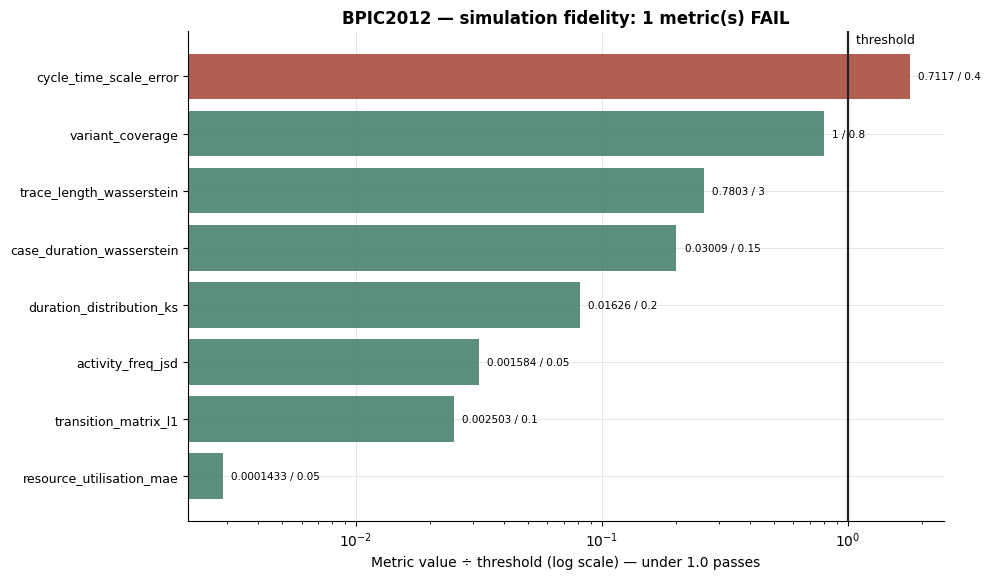

In [7]:
import figures, json

with open(OUTPUT_DIR / 'validation_modeA.json') as f:
    validation = json.load(f)

# One panel, not two. The old figure plotted metric value against threshold on
# a linear axis while the values span 5,224x on BPIC2012, so five of seven bars
# were invisible slivers; and its second panel was a pass/fail scorecard that
# repeated the first panel's colour coding.
#
# Plotting value / threshold on a log axis makes every metric comparable and
# puts the pass line at 1.0, so each metric's headroom is readable at a glance.
figures.validation_figure(validation, OUTPUT_DIR / 'validation_results.png', DATASET)

failed = [k for k, v in validation.items()
          if isinstance(v, dict) and not v['passed']]
print(f"Overall: {'PASS' if validation.get('overall_pass') else 'FAIL'}")
if failed:
    print(f"Failing metrics: {failed}")
print(f"Saved to {OUTPUT_DIR / 'validation_results.png'}")
